# Problem Type : Regression

# Task : Predict House Price

**📊 Dataset Columns**

| Feature          | Type        |
| ---------------- | ----------- |
| area             | Numerical   |
| bedrooms         | Numerical   |
| bathrooms        | Numerical   |
| stories          | Numerical   |
| mainroad         | Categorical |
| guestroom        | Categorical |
| basement         | Categorical |
| hotwaterheating  | Categorical |
| airconditioning  | Categorical |
| parking          | Numerical   |
| prefarea         | Categorical |
| furnishingstatus | Categorical |
| price            | Target      |


# **Step 1: Import Required Libraries**

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Evaluation
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

# **Step 2: Load Dataset**

In [2]:
df = pd.read_csv('/content/House Price Dataset.csv')

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# **Step 3: Basic Information**

In [3]:
print(df.shape)

(545, 13)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


# **Step 4: Check Missing Values**

In [7]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


# **Step 5: Visualize Target Variable**

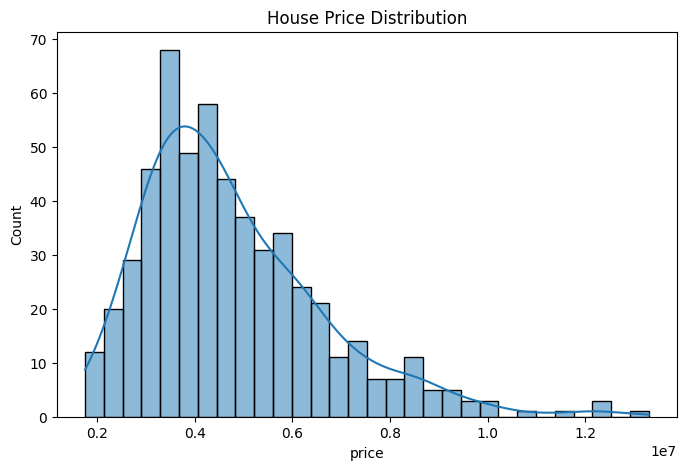

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'],
             bins=30,
             kde=True)

plt.title("House Price Distribution")
plt.show()

# **Step 6: Encode Categorical Variables**

Dataset contains:

- yes/no columns
- furnishingstatus

Convert them into numbers.

In [9]:
le = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


# **Step 7: Correlation Heatmap**

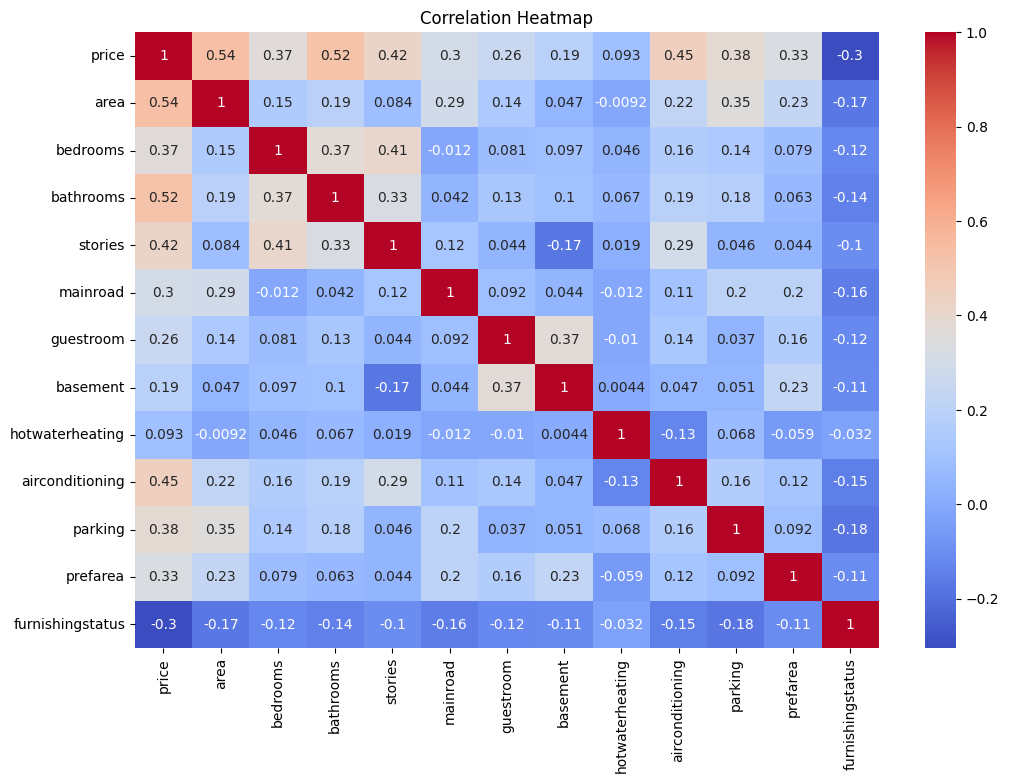

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

# **Step 8: Separate Features and Target**

In [11]:
X = df.drop('price', axis=1)

y = df['price']

# **Step 9: Train Test Split**

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(436, 12)
(109, 12)


# **Step 10: Feature Scaling**
**ANN works best on scaled data.**

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# **Step 11: Build ANN Model**
**Architecture**

```
Input Layer (12 Features)
        ↓
Dense Layer (128)
        ↓
Dropout
        ↓
Dense Layer (64)
        ↓
Dropout
        ↓
Dense Layer (32)
        ↓
Output Layer (1)
```

In [17]:
model = Sequential()

# Hidden Layer 1
model.add(Dense(
    units=128,
    activation='relu',
    input_dim=X_train.shape[1]
))

model.add(Dropout(0.2))

# Hidden Layer 2
model.add(Dense(
    units=64,
    activation='relu'
))

model.add(Dropout(0.2))

# Hidden Layer 3
model.add(Dense(
    units=32,
    activation='relu'
))

# Output Layer
model.add(Dense(
    units=1,
    activation='linear'
))

# **Step 12: Compile Model**

For Regression:

- Loss = MSE
- Optimizer = Adam

In [18]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# **Step 13: Model Summary**

In [19]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

# **Step 14: Train ANN**

In [20]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 236ms/step - loss: 25349387714560.0000 - mae: 4727422.0000 - val_loss: 24781592199168.0000 - val_mae: 4623897.0000
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 25349373034496.0000 - mae: 4727420.5000 - val_loss: 24781571227648.0000 - val_mae: 4623895.0000
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25349343674368.0000 - mae: 4727417.5000 - val_loss: 24781529284608.0000 - val_mae: 4623891.0000
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25349293342720.0000 - mae: 4727412.0000 - val_loss: 24781457981440.0000 - val_mae: 4623883.5000
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25349186387968.0000 - mae: 4727402.0000 - val_loss: 24781325860864.0000 - val_mae: 4623871.0000
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25349016518656.0000 - mae: 4727385.5000 - val_loss: 24781088882688.0000 - val_mae: 4623848.5000
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 253487124

# **Step 15: Training Loss Graph**

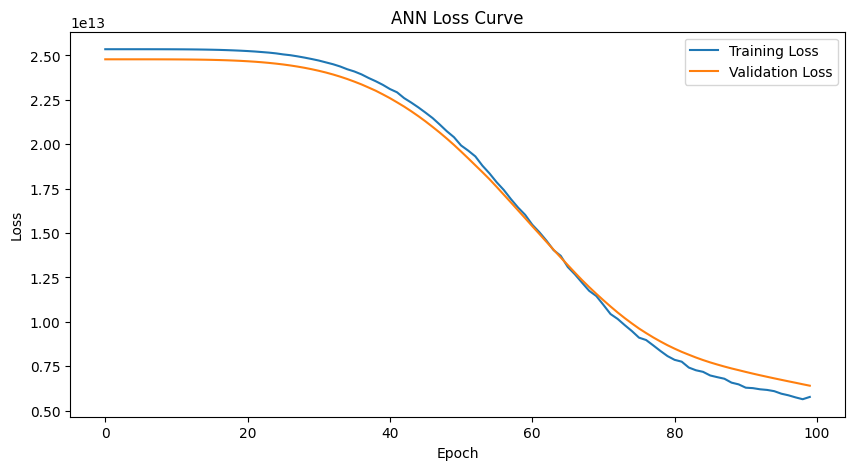

In [21]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title("ANN Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

# **Step 16: Predict House Prices**

In [22]:
y_pred = model.predict(X_test)

y_pred[:5]

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step


array([[ 887458.94],
       [7728285.  ],
       [1061532.9 ],
       [1712744.6 ],
       [ 836664.7 ]], dtype=float32)

# **Step 17: Evaluate Model**

In [24]:
mae = mean_absolute_error( y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 2277412.0
MSE : 6645946515456.0
RMSE : 2577973.334900111
R2 Score : -0.3148390054702759


# **Step 18: Actual vs Predicted Graph**

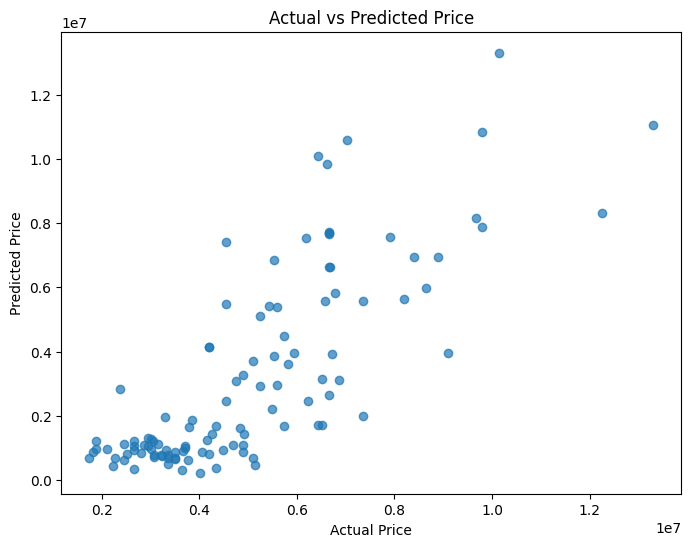

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

# **Step 19: Residual Analysis**

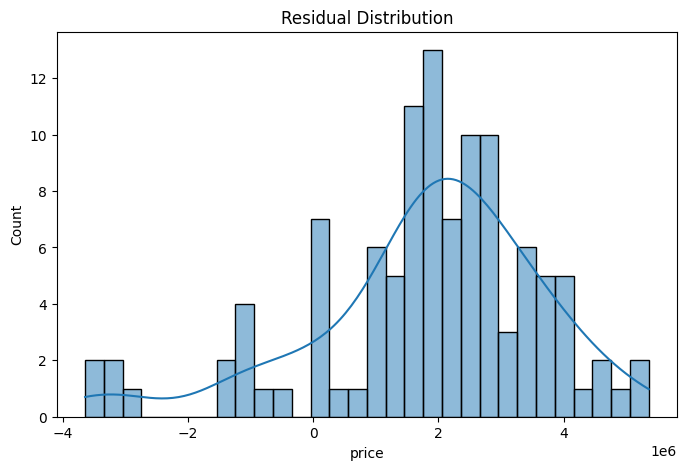

In [26]:
residuals = y_test - y_pred.flatten()

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

# **Step 20: Save ANN Model**

In [27]:
model.save("HousePrice_ANN_Model.h5")

print("Model Saved Successfully")

Model Saved Successfully


# **🔥 ANN Working Flow (Interview Important)**

```
Raw Data
   ↓
Encoding
   ↓
Train Test Split
   ↓
Feature Scaling
   ↓
Input Layer
   ↓
Hidden Layer 1 (128 Neurons)
   ↓
Hidden Layer 2 (64 Neurons)
   ↓
Hidden Layer 3 (32 Neurons)
   ↓
Output Layer (Price)
   ↓
Prediction
   ↓
MAE / RMSE / R² Evaluation
```